In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from lensim.host import Host
from lensim.simulator import Simulator
from lensim.utils import jain, tail, microsec, kB, Gbps

/home/smrn/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### 1. Prepare trainning dataset.

In [4]:
packet_size = 5e6
n_hosts = 100
n_loops = 500000
cable_delay = 50
target_delay = 400

In [5]:
%%time
net = Simulator(logger=True)
for _ in range(n_hosts):
    net.add(Host((0, n_loops), cable_delay, target_delay, cwnd=1.5))
lenq, t_acks, cwnds, rtts, throughputs = net.simulate(n_loops, settling=n_loops//2)
all_rtts = np.concatenate(rtts)
tail99 = tail(all_rtts, 0.99)
print("=== Simulation results ===")
print(f'Throughput: {50*throughputs.sum():.1f} Gbps')
print(f"Mean RTT: {np.mean(all_rtts)*1.6e-07/microsec:.1f} us")
print(f"99th-p RTT: {tail99*1.6e-07/microsec:.1f} us")
print(f"Jain's fairness: J={jain(throughputs):.3f}")

Log saved to network_log1
[0]
=== Simulation results ===
Throughput: 50.0 Gbps
Mean RTT: 28.7 us
99th-p RTT: 35.2 us
Jain's fairness: J=1.000
CPU times: user 13.8 s, sys: 286 ms, total: 14.1 s
Wall time: 14.2 s


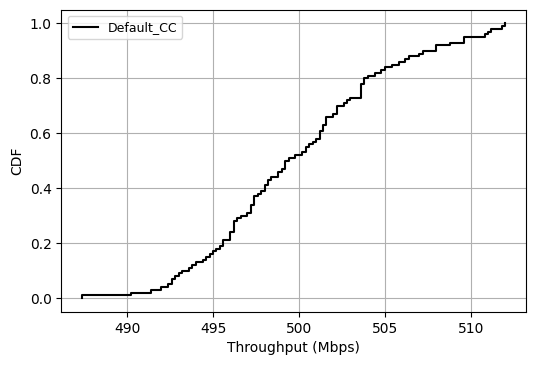

In [6]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(1,1, figsize=(6, 4), dpi=100)
ax.ecdf(50e3*throughputs, c='k', label='Default_CC')
ax.grid()
ax.set_ylim([-0.05,1.05])
ax.set_xlabel('Throughput (Mbps)')
ax.set_ylabel('CDF')
ax.legend(loc = 'upper left', fontsize=9)

### 2. Train model

In [4]:
from sklearn.model_selection import train_test_split 
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from regrsim.simulator import NewSimulator
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
import joblib

In [5]:
lines = []
with open('./log/network_log1', 'r') as file:
    lines = file.readlines()
    
X = [s.split(',')[1:11] for s in lines][1:] # cwnd_prev,can_decrease,target_delay,total_acked,pacing_delay,first,rtt,prev_rtt,delay,now
y = [s.split(',')[11] for s in lines][1:] # cwnd
for fs in X: del fs[5]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

model = SVR(verbose=True)
params = {
    'C': [1],              
    'epsilon': [0.1],      
    'kernel': ['linear'],     
    'gamma': ['scale']     
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=params,
    scoring='r2',          
    cv=2,
    verbose=4,
    n_jobs=-1,
    refit='r2'        
)

# Обучение модели
grid_search.fit(X, y)

Fitting 2 folds for each of 1 candidates, totalling 2 fits
...............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................